### Assignment #9 Time series analysis

In [28]:
import os
import warnings

warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import requests
from pathlib import Path
from plotly import __version__
from plotly import graph_objs as go
from plotly.offline import download_plotlyjs, init_notebook_mode, iplot, plot
from IPython.display import display, IFrame

print(__version__)  # need 1.9.0 or greater
init_notebook_mode(connected=True)

6.7.0


In [29]:
def plotly_df(df, title="", width=800, height=500):
    """Visualize all the dataframe columns as line plots."""
    common_kw = dict(x=df.index, mode="lines")
    data = [go.Scatter(y=df[c], name=c, **common_kw) for c in df.columns]
    layout = dict(title=title)
    fig = dict(data=data, layout=layout)

    # in a Jupyter Notebook, the following should work
    #iplot(fig, show_link=False)

    # in a Jupyter Book, we save a plot offline and then render it with IFrame
    plot_path = f"../../_static/plotly_htmls/{title}.html".replace(" ", "_")
    plot(fig, filename=plot_path, show_link=False, auto_open=False);
    display(IFrame(plot_path, width=width, height=height))

In [30]:
# for Jupyter-book, we copy data from GitHub, locally, to save Internet traffic,
# you can specify the data/ folder from the root of your cloned
# https://github.com/Yorko/mlcourse.ai repo, to save Internet traffic
DATA_PATH = "https://raw.githubusercontent.com/Yorko/mlcourse.ai/main/data/"

In [31]:
df = pd.read_csv(DATA_PATH + "wiki_machine_learning.csv", sep=" ")
df = df[df["count"] != 0]
df.head()

,date,count,lang,page,rank,month,title
81,2015-01-01,1414,en,Machine_learning,8708,201501,Machine_learning
80,2015-01-02,1920,en,Machine_learning,8708,201501,Machine_learning
79,2015-01-03,1338,en,Machine_learning,8708,201501,Machine_learning
78,2015-01-04,1404,en,Machine_learning,8708,201501,Machine_learning
77,2015-01-05,2264,en,Machine_learning,8708,201501,Machine_learning


In [32]:
df.shape

(383, 7)

In [33]:
df.date = pd.to_datetime(df.date)

In [34]:
def plotly_df(df, title="plot", width=1000, height=500):
    data = [
        go.Scatter(x=df.index, y=df[column], mode="lines", name=column)
        for column in df.columns
    ]
    fig = go.Figure(data=data)
    
    local_dir = Path("./_static/plotly_htmls")
    local_dir.mkdir(parents=True, exist_ok=True)
    
    plot_path = local_dir / f"{title.replace(' ', '_')}.html"
    plot(fig, filename=str(plot_path), show_link=False, auto_open=False)
    return display(IFrame(str(plot_path), width=width, height=height))

plotly_df(df=df.set_index("date")[["count"]], title="assign9_plot")

In [35]:
from prophet import Prophet

In [36]:
predictions = 30

df = df[["date", "count"]]
df.columns = ["ds", "y"]
df.tail()

,ds,y
382,2016-01-16,1644
381,2016-01-17,1836
376,2016-01-18,2983
375,2016-01-19,3389
372,2016-01-20,3559


#### Question 1:
What is the prediction of the number of views of the wiki page on January 20? Round to the nearest integer.

In [37]:
train_df = df[:-predictions]

In [38]:
m = Prophet()
m.fit(train_df)

07:02:28 - cmdstanpy - INFO - Chain [1] start processing
07:02:32 - cmdstanpy - INFO - Chain [1] done processing


In [39]:
future = m.make_future_dataframe(periods=predictions)
forecast = m.predict(future)

In [40]:
forecast[forecast['ds'] == '2016-01-20'][['ds', 'yhat']]

,ds,yhat
382,2016-01-20,3420.640949


Estimate the quality of the prediction with the last 30 points.

In [41]:
cmp_df = forecast.set_index('ds')[['yhat', 'yhat_lower', 'yhat_upper']].join(df.set_index('ds'))
cmp_df.tail(30)

,yhat,yhat_lower,yhat_upper,y
ds,,,,
2015-12-22,3382.082783,2994.322787,3819.031422,2469
2015-12-23,3271.513747,2868.040236,3677.611158,2292
2015-12-24,3178.360440,2737.223259,3605.210395,1671
2015-12-25,2863.782520,2448.475405,3291.784774,1227
2015-12-26,2000.345039,1609.653984,2375.845900,1367
2015-12-27,2146.654798,1731.253502,2539.203759,1373
2015-12-28,3154.083215,2768.140690,3582.852539,2181
2015-12-29,3419.364583,3029.857149,3815.568577,2162
2015-12-30,3308.795547,2874.041978,3707.476001,2107


#### Question 2:
What is MAPE equal to?

In [42]:
cmp_df['e'] = cmp_df['y'] - cmp_df['yhat']
cmp_df['p'] = 100 * cmp_df['e'] / cmp_df['y']

mape = cmp_df[-predictions:]['p'].abs().mean()
mae = cmp_df[-predictions:]['e'].abs().mean()

print("MAPE:", mape)
print("MAE:", mae)

MAPE: 34.302064247488765
MAE: 595.6231607868056


### Question 3: 
What is MAE equal to?

In [43]:
cmp_df['e'] = cmp_df['y'] - cmp_df['yhat']
cmp_df['p'] = 100 * cmp_df['e'] / cmp_df['y']

mape = cmp_df[-predictions:]['p'].abs().mean()
mae = cmp_df[-predictions:]['e'].abs().mean()

print("MAPE:", mape)
print("MAE:", mae)

MAPE: 34.302064247488765
MAE: 595.6231607868056


Predicting with ARIMA

In [20]:
%matplotlib inline
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats

plt.rcParams["figure.figsize"] = (15, 10)

#### Question 4: 
Let’s verify the stationarity of the series using the Dickey-Fuller test. Is the series stationary? What is the p-value?

Dickey-Fuller test: p=0.015384


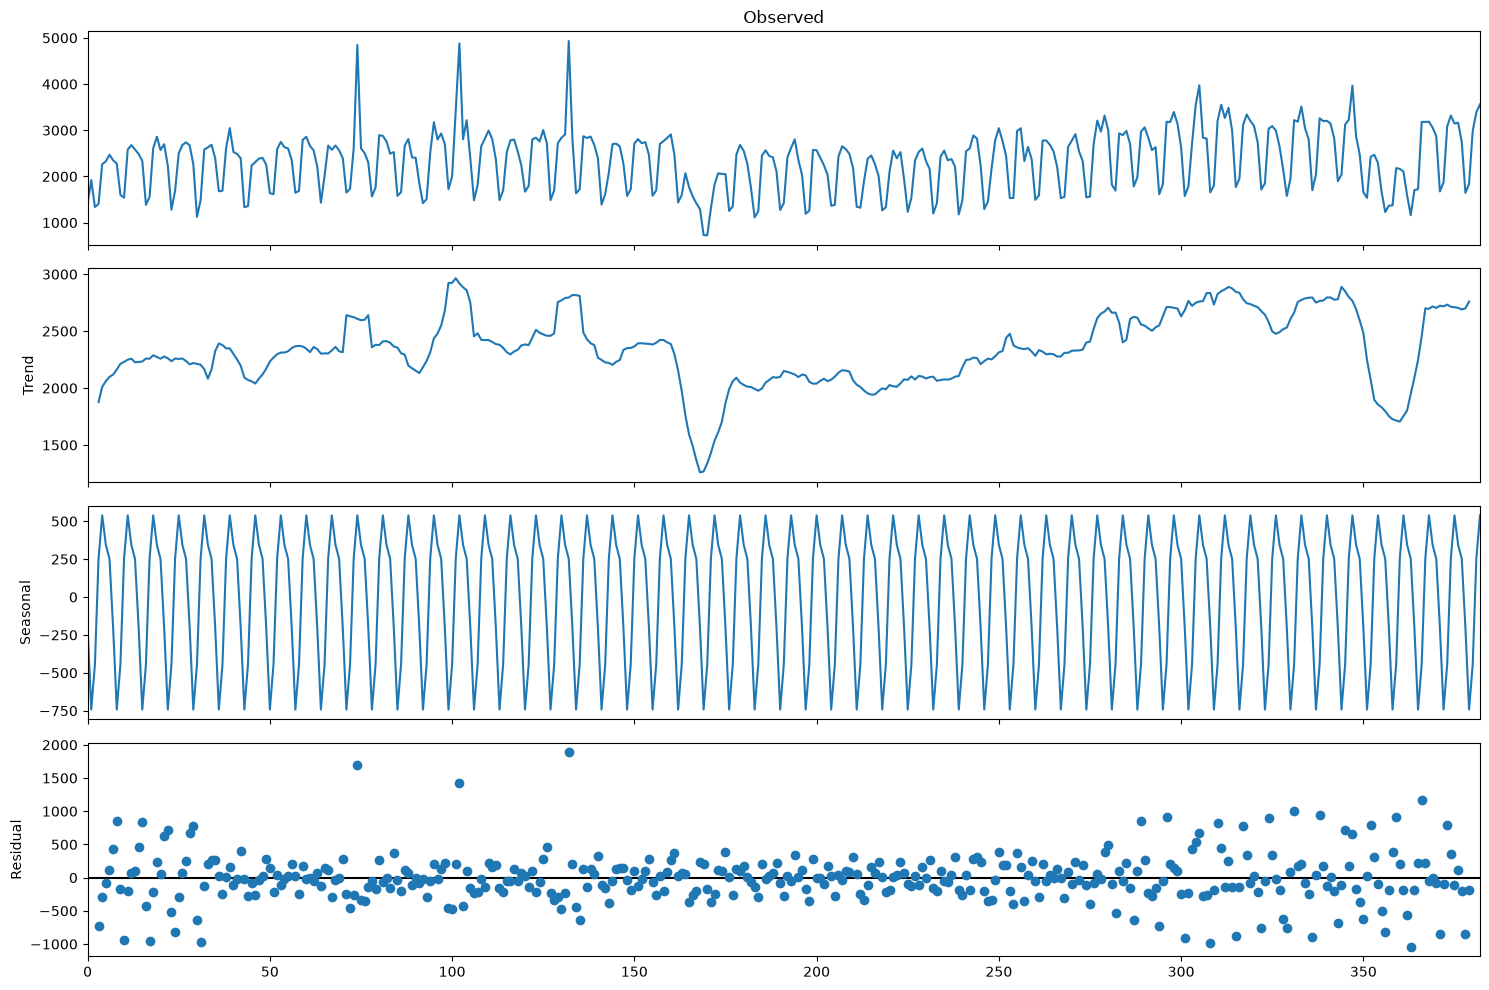

In [44]:
sm.tsa.seasonal_decompose(df['y'].values, period=7).plot()

print("Dickey-Fuller test: p=%f" % sm.tsa.stattools.adfuller(df['y'])[1])

Next, we turn to the construction of the SARIMAX model (sm.tsa.statespace.SARIMAX).
#### Question 5: 
What parameters are the best for the model according to the AIC criterion?

In [45]:
from itertools import product

ps = range(0, 5)
d = 1
qs = range(0, 4)
Ps = range(0, 5)
D = 1
Qs = range(0, 2)

parameters = product(ps, qs, Ps, Qs)
parameters_list = list(parameters)
len(parameters_list)

200

In [46]:
%%time
import warnings
from tqdm.notebook import tqdm

results = []
best_aic = float("inf")
warnings.filterwarnings("ignore")

for param in tqdm(parameters_list):
    try:
        model = sm.tsa.statespace.SARIMAX(
            df['y'],
            order=(param[0], d, param[1]),
            seasonal_order=(param[2], D, param[3], 7)
        ).fit(disp=-1)
    except (ValueError, np.linalg.LinAlgError):
        continue
    aic = model.aic
    if aic < best_aic:
        best_model = model
        best_aic = aic
        best_param = param
    results.append([param, model.aic])

  0%|          | 0/200 [00:00<?, ?it/s]

CPU times: total: 4h 29min 5s
Wall time: 1h 14min 31s


In [47]:
print(best_param)
print(best_aic)

(3, 1, 3, 0)
5471.413311578086


In [48]:
print(best_model.summary())

                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                  383
Model:             SARIMAX(3, 1, 1)x(3, 1, [], 7)   Log Likelihood               -2727.707
Date:                            Sun, 30 Aug 2026   AIC                           5471.413
Time:                                    08:38:37   BIC                           5502.829
Sample:                                         0   HQIC                          5483.885
                                            - 383                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5053      0.032     15.935      0.000       0.443       0.567
ar.L2         -0.0174      0.055   